In [7]:
import torch.nn as nn
import torch

In [8]:
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm.notebook import tqdm


### Dataset Preparation (MNIST Handwritten)

In [ ]:
# Define transformations for MNIST Handwritten
transform_mnist = transforms.Compose([
    transforms.RandomRotation(degrees=10), # random rotation for data augmentation
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST Handwritten training and test datasets
trainset_mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)

transform_mnist = transforms.Compose([
    # transforms.RandomRotation(degrees=10), # random rotation for data augmentation
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

testset_mnist = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

# Create data loaders
batch_size = 512
trainloader_mnist = torch.utils.data.DataLoader(trainset_mnist, batch_size=batch_size, shuffle=True)
testloader_mnist = torch.utils.data.DataLoader(testset_mnist, batch_size=batch_size, shuffle=False)

print(f"MNIST Handwritten training samples: {len(trainset_mnist)}")
print(f"MNIST Handwritten test samples: {len(testset_mnist)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]

MNIST Handwritten training samples: 60000
MNIST Handwritten test samples: 10000


### Install MedMNIST

In [10]:
!pip install medmnist


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 579.9 kB/s eta 0:00:00


### Dataset Preparation (PneumoniaMNIST)

In [ ]:
import medmnist
from medmnist import INFO, Evaluator

# Define transformations for PneumoniaMNIST
# Note: MedMNIST datasets are typically 28x28, so resize to 32x32 for LeNet
transform_pneumonia = transforms.Compose([
    transforms.ColorJitter(contrast=0.5),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) # Common normalization for image data
])

# Load PneumoniaMNIST training and test datasets
data_flag = 'pneumoniamnist'
info = INFO[data_flag]

# MedMNIST datasets are typically 1 channel (grayscale) and have num_classes for output_size
# We also need to reshape the labels from (N, 1) to (N,) for CrossEntropyLoss

trainset_pneumonia = medmnist.PneumoniaMNIST(split='train', transform=transform_pneumonia, download=True)
trainset_pneumonia.labels = trainset_pneumonia.labels.squeeze()

transform_pneumonia = transforms.Compose([
    # transforms.ColorJitter(contrast=0.5),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) # Common normalization for image data
])


testset_pneumonia = medmnist.PneumoniaMNIST(split='test', transform=transform_pneumonia, download=True)
testset_pneumonia.labels = testset_pneumonia.labels.squeeze()

# Create data loaders
trainloader_pneumonia = torch.utils.data.DataLoader(trainset_pneumonia, batch_size=batch_size, shuffle=True)
testloader_pneumonia = torch.utils.data.DataLoader(testset_pneumonia, batch_size=batch_size, shuffle=False)

print(f"PneumoniaMNIST training samples: {len(trainset_pneumonia)}")
print(f"PneumoniaMNIST test samples: {len(testset_pneumonia)}")

100%|██████████| 4.17M/4.17M [00:07<00:00, 583kB/s]


PneumoniaMNIST training samples: 4708
PneumoniaMNIST test samples: 624


### Dataset Preparation (MNIST Fashion)

In [ ]:
# Define transformations for MNIST Fashion (same as Handwritten for input size consistency)
transform_fashion = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Common normalization for Fashion MNIST
])

# Load MNIST Fashion training and test datasets
trainset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_fashion)

transform_fashion = transforms.Compose([
    # transforms.RandomRotation(degrees=10),
    transforms.Pad(2), # LeNet expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Common normalization for Fashion MNIST
])

testset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_fashion)

# Create data loaders
trainloader_fashion = torch.utils.data.DataLoader(trainset_fashion, batch_size=batch_size, shuffle=True)
testloader_fashion = torch.utils.data.DataLoader(testset_fashion, batch_size=batch_size, shuffle=False)

print(f"MNIST Fashion training samples: {len(trainset_fashion)}")
print(f"MNIST Fashion test samples: {len(testset_fashion)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.50MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.6MB/s]

MNIST Fashion training samples: 60000
MNIST Fashion test samples: 10000


### Training and Evaluation Functions

In [13]:
def train_model(model, trainloader, criterion, optimizer, num_epochs=10, device='cpu', scheduler=None):
    model.train()
    model.to(device)
    history = {'loss': [], 'acc': []}

    for epoch in range(num_epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100. * correct / total
        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%, LR: {current_lr}')

        if scheduler is not None:
            scheduler.step()

    return history

In [14]:
def evaluate_model(model, testloader, device='cpu', print_metrics=True):
    model.eval()
    model.to(device)
    correct = 0
    total = 0
    all_labels = []
    all_predicted = []

    with torch.no_grad():
        for data in tqdm(testloader, desc="[Evaluating]", leave=False):
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_predicted.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_predicted, average='weighted')
    recall = recall_score(all_labels, all_predicted, average='weighted')
    precision = precision_score(all_labels, all_predicted, average='weighted')

    if print_metrics:
        print(f'Accuracy on the test set: {accuracy:.2f}%')
        print(f'F1-Score (weighted): {f1:.2f}')
        print(f'Recall (weighted): {recall:.2f}')
        print(f'Precision (weighted): {precision:.2f}')

    return accuracy, f1, recall, precision

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

def plot_history(history, title="Training History"):
    """Vẽ biểu đồ Loss và Accuracy từ lịch sử huấn luyện"""
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color='tab:red')
    ax1.plot(history['loss'], color='tab:red', label='Loss')
    ax1.tick_params(axis='y', labelcolor='tab:red')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Accuracy (%)', color='tab:blue')
    ax2.plot(history['acc'], color='tab:blue', label='Accuracy')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    plt.title(title)
    fig.tight_layout()
    plt.show()

def plot_confusion_matrix(model, testloader, device, classes, title="Confusion Matrix"):
    """Dự đoán và vẽ ma trận nhầm lẫn"""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

In [16]:
# changing the lenet with newer code style -> increase nums of params but it may be better, and have no different about speed

class Lenet(nn.Module):
  def __init__(self, input_size, output_size): # the input size should be 32 with padding
    super(Lenet, self).__init__()

    self.c1 = nn.Conv2d(1, 6, kernel_size=5, stride=1)
    self.bn1 = nn.BatchNorm2d(6) # BN cho 6 kênh của C1
    self.s2 = nn.MaxPool2d(2, 2)
    self.c3 = nn.Conv2d(6, 16, kernel_size=5,stride=1)
    self.bn3 = nn.BatchNorm2d(16) # BN cho 16 kênh sau khi cat ở C3
    self.s4 = nn.MaxPool2d(2, 2)
    self.c5 = nn.Conv2d(16, 120, stride=1, kernel_size=5)
    self.bn5 = nn.BatchNorm2d(120)
    self.fc6 = nn.Linear(120, 84)
    self.bn6 = nn.BatchNorm1d(84)

    self.output = nn.Linear(84, output_size)

  def forward(self, x):

    # Inserts a dimension with a size of one (a singleton dimension) into the tensor's shape.
    if x.dim() == 3:
      x = x.unsqueeze(0)

    x = self.bn1(self.c1(x))
    x = torch.relu(self.s2(x))
    x = self.bn3(self.c3(x))
    x = torch.relu(self.s4(x))
    x = self.bn5(self.c5(x))

    # x is now of shape (N, 120, 1, 1) and need to be at shape (N, 120) to proceed so we use x.view

    x = x.view(x.shape[0], -1)

    x = torch.relu(self.bn6(self.fc6(x)))

    return self.output(x)


In [17]:
# changing the lenet with newer code style -> increase nums of params but it may be better, and have no different about speed

class LenetDropout(nn.Module):
  def __init__(self, input_size, output_size): # the input size should be 32 with padding
    super(LenetDropout, self).__init__()

    self.c1 = nn.Conv2d(1, 6, kernel_size=5, stride=1)
    self.bn1 = nn.BatchNorm2d(6) # BN cho 6 kênh của C1
    self.s2 = nn.MaxPool2d(2, 2)
    self.c3 = nn.Conv2d(6, 16, kernel_size=5,stride=1)
    self.bn3 = nn.BatchNorm2d(16) # BN cho 16 kênh sau khi cat ở C3
    self.s4 = nn.MaxPool2d(2, 2)
    self.c5 = nn.Conv2d(16, 120, stride=1, kernel_size=5)
    self.bn5 = nn.BatchNorm2d(120)
    self.fc6 = nn.Linear(120, 84)
    self.bn6 = nn.BatchNorm1d(84)

    self.output = nn.Linear(84, output_size)

    self.dropout = nn.Dropout(0.5)

  def forward(self, x):
    if x.dim() == 3:
        x = x.unsqueeze(0)

    # --- Khối 1 ---
    x = self.c1(x)
    x = self.bn1(x)
    x = torch.relu(x)      # Kích hoạt (lọc nhiễu âm) TRƯỚC
    x = self.s2(x)         # Pooling (nén đặc trưng) SAU

    # --- Khối 2 ---
    x = self.c3(x)
    x = self.bn3(x)
    x = torch.relu(x)      # Kích hoạt TRƯỚC
    x = self.s4(x)         # Pooling SAU

    # --- Khối 3 ---
    x = self.c5(x)
    x = self.bn5(x)
    x = torch.relu(x)

    # --- Flatten ---
    x = x.view(x.shape[0], -1)

    # --- Khối FC ---
    x = self.fc6(x)
    x = self.bn6(x)
    x = torch.relu(x)
    x = self.dropout(x)    # Dropout 0.5 hoạt động cực tốt ở đây

    return self.output(x)

In [18]:
from sklearn.metrics import f1_score, recall_score, precision_score

### LeNet on MNIST Handwritten


--- Training LeNet on MNIST Handwritten ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.1758, Acc: 95.15%, LR: 0.01


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.0581, Acc: 98.15%, LR: 0.01


...

Epoch 28, Loss: 0.0097, Acc: 99.71%, LR: 0.0001


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0105, Acc: 99.68%, LR: 0.0001


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0100, Acc: 99.70%, LR: 0.0001


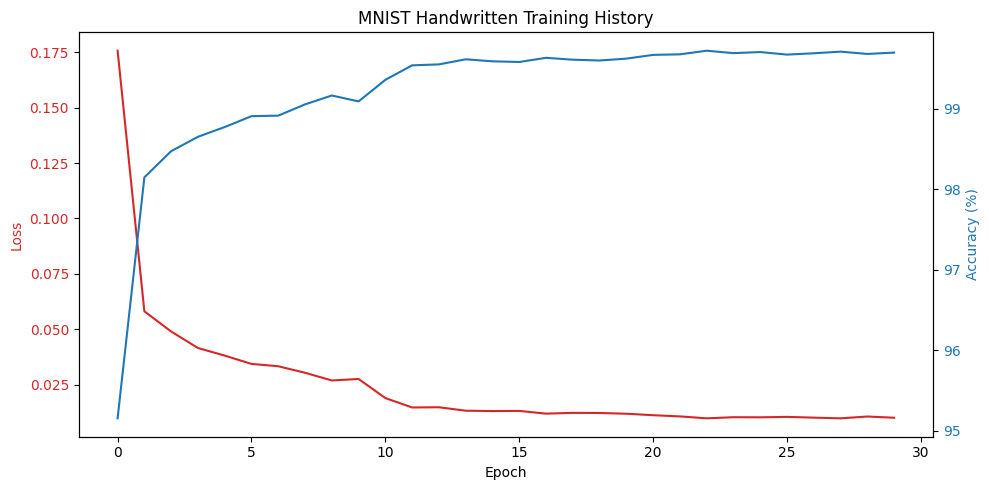

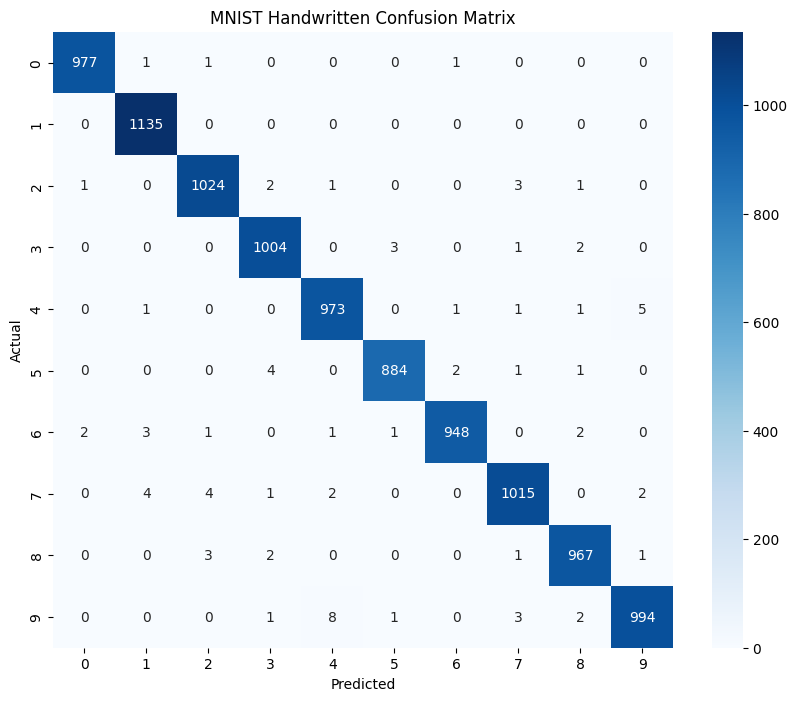

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 99.30%
F1-Score (weighted): 0.99
Recall (weighted): 0.99
Precision (weighted): 0.99


In [19]:
print("\n--- Training LeNet on MNIST Handwritten ---")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lenet_mnist = Lenet(input_size=32, output_size=10)
criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(lenet_mnist.parameters(), lr=0.01)
# Khởi tạo scheduler
scheduler_mnist = optim.lr_scheduler.StepLR(optimizer_mnist, step_size=10, gamma=0.1)

# Huấn luyện với scheduler
history_mnist = train_model(lenet_mnist, trainloader_mnist, criterion_mnist, optimizer_mnist, num_epochs=30, device=device, scheduler=scheduler_mnist)
plot_history(history_mnist, title="MNIST Handwritten Training History")

classes_mnist = [str(i) for i in range(10)]
plot_confusion_matrix(lenet_mnist, testloader_mnist, device, classes_mnist, title="MNIST Handwritten Confusion Matrix")
accuracy_mnist, f1_mnist, recall_mnist, precision_mnist = evaluate_model(lenet_mnist, testloader_mnist, device=device)

In [20]:
accuracy_mnist, f1_mnist, recall_mnist, precision_mnist = evaluate_model(lenet_mnist, testloader_mnist, device=device)

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 99.17%
F1-Score (weighted): 0.99
Recall (weighted): 0.99
Precision (weighted): 0.99


### LeNet on MNIST Fashion

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
# LeNetWide class definition with fix
class LeNetWide(nn.Module):
    def __init__(self, output_size=10):
        super(LeNetWide, self).__init__()

        # --- Khối 1: Tăng từ 6 lên 32 filters ---
        # Input: 28x28. Thêm padding=2 để ảnh lên 32x32 -> Output: 32 channels, 28x28
        self.c1 = nn.Conv2d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(32)
        self.s2 = nn.MaxPool2d(2, 2) # Output: 32 channels, 14x14

        # --- Khối 2: Tăng từ 16 lên 64 filters ---
        # Dùng Conv2d tiêu chuẩn thay vì c3_indices phức tạp
        self.c3 = nn.Conv2d(32, 64, kernel_size=5) # Output: 64 channels, 10x10
        self.bn3 = nn.BatchNorm2d(64)
        self.s4 = nn.MaxPool2d(2, 2) # Output: 64 channels, 5x5

        # --- Khối 3: Tăng từ 120 lên 256 filters ---
        self.c5 = nn.Conv2d(64, 256, kernel_size=5) # Output: 256 channels, 1x1
        self.bn5 = nn.BatchNorm2d(256)

        # --- Khối Fully Connected: Tăng từ 84 lên 128 ---
        # FIX: Changed input features from 256 to 1024
        self.fc6 = nn.Linear(1024, 128)
        self.bn6 = nn.BatchNorm1d(128)

        self.output = nn.Linear(128, output_size)

        # Dropout 0.5 để chống overfit do lượng tham số đã tăng lên nhiều
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(0)

        # Khối 1
        x = self.c1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.s2(x)

        # Khối 2
        x = self.c3(x)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.s4(x)

        # Khối 3
        x = self.c5(x)
        x = self.bn5(x)
        x = torch.relu(x)

        # Flatten [Batch, 256, 1, 1] -> [Batch, 256]
        x = x.view(x.size(0), -1)

        # Khối FC
        x = self.fc6(x)
        x = self.bn6(x)
        x = torch.relu(x)
        x = self.dropout(x)

        return self.output(x)


--- Training LeNet on MNIST Fashion ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.5537, Acc: 82.23%, LR: 0.001


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.3400, Acc: 88.13%, LR: 0.001


...

Epoch 28, Loss: 0.1124, Acc: 96.04%, LR: 1e-05


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.1134, Acc: 96.01%, LR: 1e-05


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.1121, Acc: 95.97%, LR: 1e-05


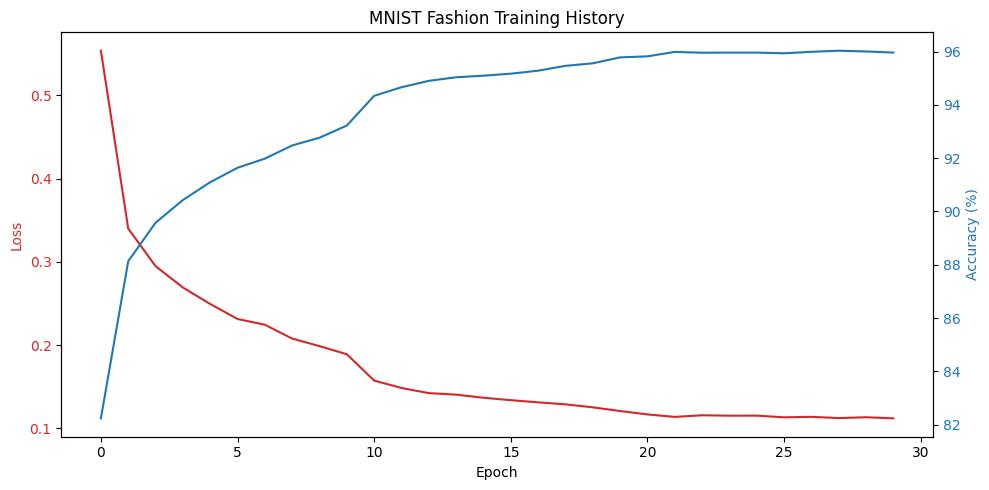

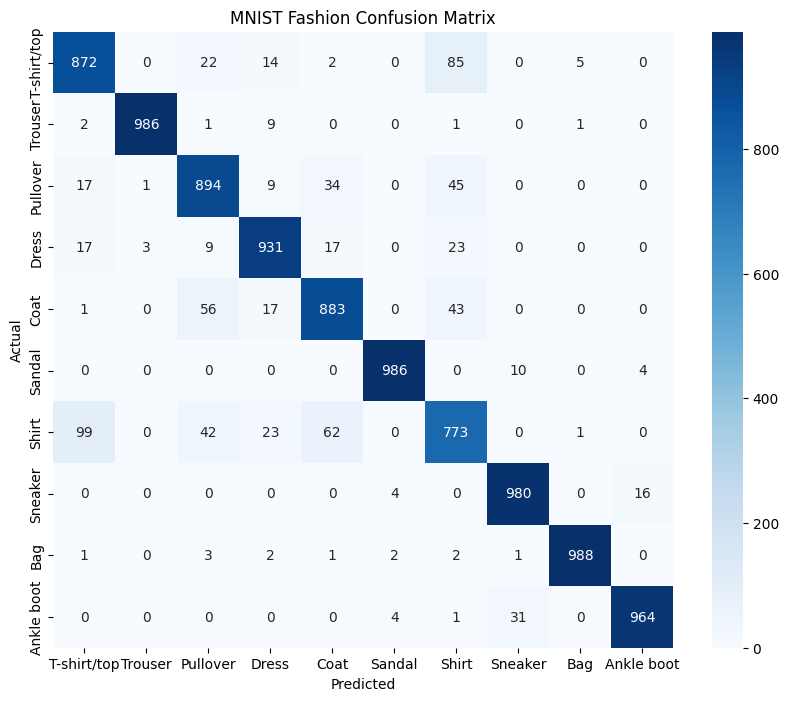

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 92.55%
F1-Score (weighted): 0.93
Recall (weighted): 0.93
Precision (weighted): 0.93


In [27]:


print("\n--- Training LeNet on MNIST Fashion ---")
lenet_fashion = LeNetWide(output_size=10)
criterion_fashion = nn.CrossEntropyLoss()
optimizer_fashion = optim.Adam(lenet_fashion.parameters(), lr=0.001)
scheduler_fashion = optim.lr_scheduler.StepLR(optimizer_fashion, step_size=10, gamma=0.1)

history_fashion = train_model(lenet_fashion, trainloader_fashion, criterion_fashion, optimizer_fashion, num_epochs=30, device=device, scheduler=scheduler_fashion)
plot_history(history_fashion, title="MNIST Fashion Training History")

classes_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plot_confusion_matrix(lenet_fashion, testloader_fashion, device, classes_fashion, title="MNIST Fashion Confusion Matrix")
accuracy_fashion, f1_fashion, recall_fashion, precision_fashion = evaluate_model(lenet_fashion, testloader_fashion, device=device)

In [28]:
import torch
import torch.nn as nn

class LeNetWide_3x3(nn.Module):
    def __init__(self, output_size=10):
        super(LeNetWide_3x3, self).__init__()

        # Khối 1: Dùng kernel 3x3, padding 1
        self.c1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.s2 = nn.MaxPool2d(2, 2)

        # Khối 2: Tăng filter lên 64, kernel 3x3
        self.c3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.s4 = nn.MaxPool2d(2, 2)

        # Khối 3: Tăng filter lên 128, kernel 3x3
        self.c5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)

        # ĐIỂM SÁNG: Ép đầu ra của C5 luôn về kích thước 2x2 bất kể ảnh gốc như thế nào
        self.pool_final = nn.AdaptiveAvgPool2d((2, 2))

        # FC Layer: 128 kênh x kích thước 2x2 = 512
        self.fc6 = nn.Linear(128 * 2 * 2, 128)
        self.bn6 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.5)

        self.output = nn.Linear(128, output_size)

    def forward(self, x):
        if x.dim() == 3: x = x.unsqueeze(0)

        # Block 1
        x = self.s2(torch.relu(self.bn1(self.c1(x))))
        # Block 2
        x = self.s4(torch.relu(self.bn3(self.c3(x))))
        # Block 3
        x = torch.relu(self.bn5(self.c5(x)))

        # Ép về 2x2
        x = self.pool_final(x)

        # Flatten (Batch_size, 128 * 2 * 2)
        x = x.view(x.size(0), -1)

        # FC Block
        x = self.dropout(torch.relu(self.bn6(self.fc6(x))))

        return self.output(x)


--- Training LeNet on MNIST Fashion ---


Epoch 1/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 1, Loss: 0.6487, Acc: 79.77%, LR: 0.001


Epoch 2/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2, Loss: 0.3675, Acc: 87.38%, LR: 0.001


...

Epoch 28, Loss: 0.1722, Acc: 93.92%, LR: 1e-05


Epoch 29/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 29, Loss: 0.1724, Acc: 93.91%, LR: 1e-05


Epoch 30/30:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 30, Loss: 0.1719, Acc: 93.89%, LR: 1e-05


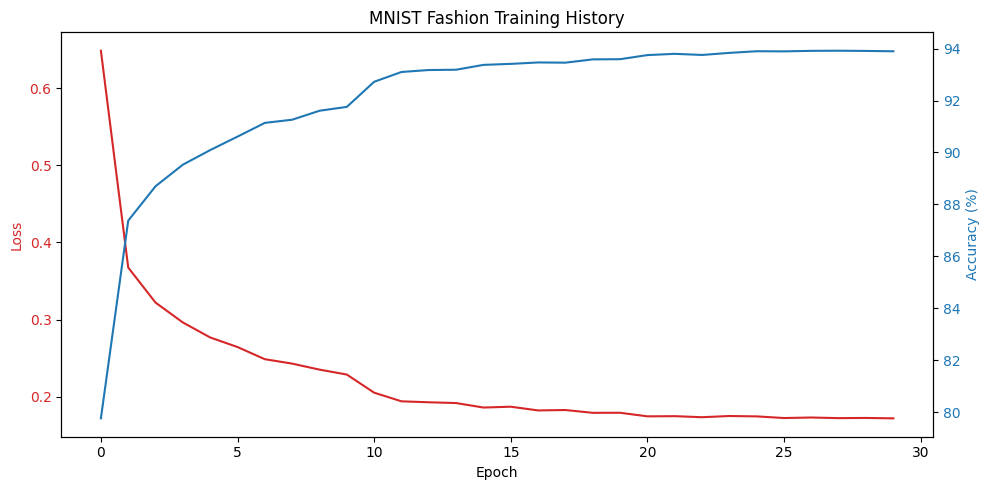

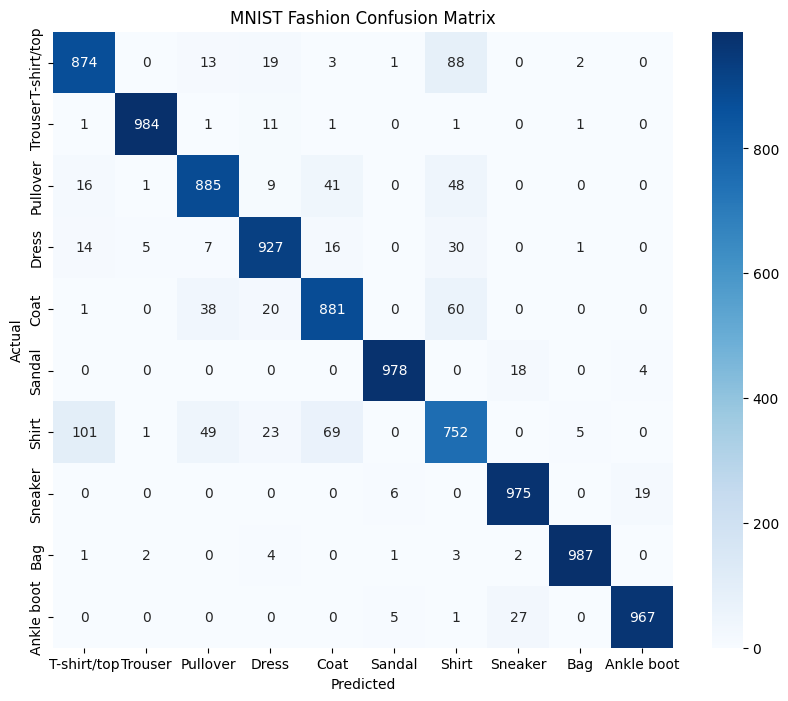

[Evaluating]:   0%|          | 0/20 [00:00<?, ?it/s]

Accuracy on the test set: 92.26%
F1-Score (weighted): 0.92
Recall (weighted): 0.92
Precision (weighted): 0.92


In [29]:


print("\n--- Training LeNet on MNIST Fashion ---")
lenet_fashion = LeNetWide_3x3(output_size=10)
criterion_fashion = nn.CrossEntropyLoss()
optimizer_fashion = optim.Adam(lenet_fashion.parameters(), lr=0.001)
scheduler_fashion = optim.lr_scheduler.StepLR(optimizer_fashion, step_size=10, gamma=0.1)

history_fashion = train_model(lenet_fashion, trainloader_fashion, criterion_fashion, optimizer_fashion, num_epochs=30, device=device, scheduler=scheduler_fashion)
plot_history(history_fashion, title="MNIST Fashion Training History")

classes_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plot_confusion_matrix(lenet_fashion, testloader_fashion, device, classes_fashion, title="MNIST Fashion Confusion Matrix")
accuracy_fashion, f1_fashion, recall_fashion, precision_fashion = evaluate_model(lenet_fashion, testloader_fashion, device=device)

### LeNet on PneumoniaMNIST


--- Training LeNet on PneumoniaMNIST ---


Epoch 1/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1, Loss: 0.5975, Acc: 70.52%, LR: 0.01


Epoch 2/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2, Loss: 0.2797, Acc: 88.02%, LR: 0.01


...

Epoch 28, Loss: 0.0773, Acc: 97.18%, LR: 0.0001


Epoch 29/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0684, Acc: 97.28%, LR: 0.0001


Epoch 30/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0709, Acc: 97.18%, LR: 0.0001


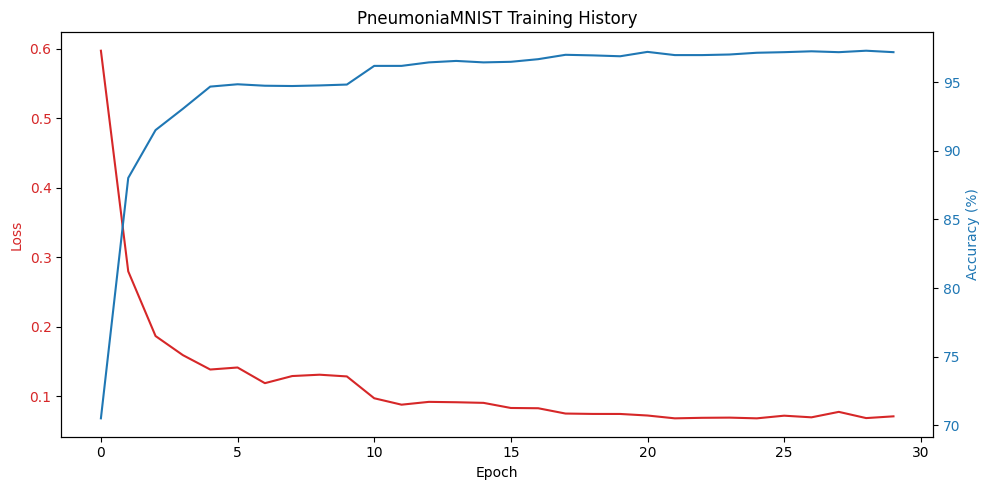

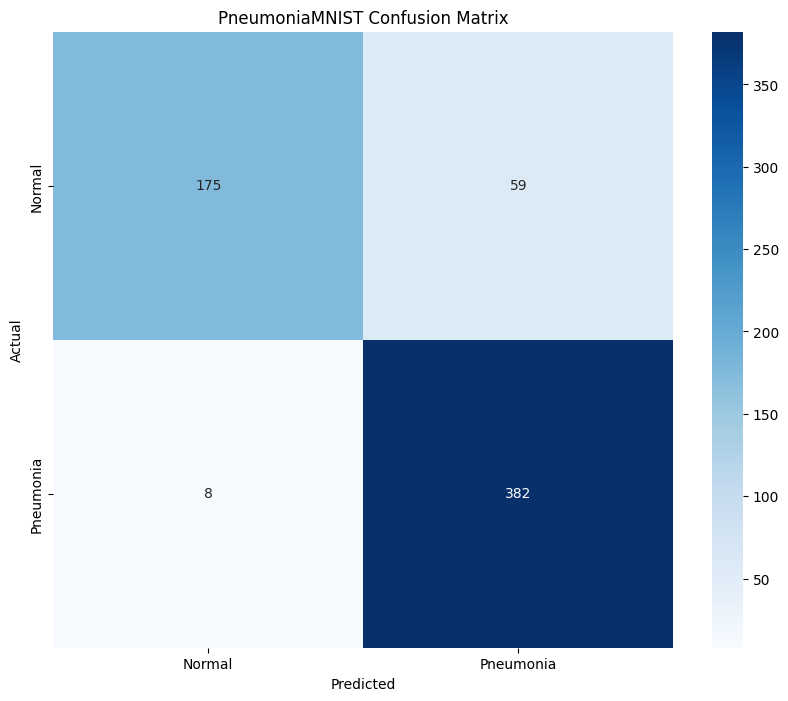

[Evaluating]:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 89.42%
F1-Score (weighted): 0.89
Recall (weighted): 0.89
Precision (weighted): 0.90


In [31]:
print("\n--- Training LeNet on PneumoniaMNIST ---")
# Calculate class weights for PneumoniaMNIST
class_counts = torch.bincount(torch.tensor(trainset_pneumonia.labels))
total_samples = class_counts.sum().item()
num_classes = len(class_counts)
class_weights = total_samples / (num_classes * class_counts.float())
class_weights = class_weights.to(device)

lenet_pneumonia = LeNetWide_3x3(output_size=2)
criterion_pneumonia = nn.CrossEntropyLoss(weight=class_weights) # Apply weighted loss
optimizer_pneumonia = optim.Adam(lenet_pneumonia.parameters(), lr=0.01)
scheduler_pneumonia = optim.lr_scheduler.StepLR(optimizer_pneumonia, step_size=10, gamma=0.1)

history_pneumonia = train_model(lenet_pneumonia, trainloader_pneumonia, criterion_pneumonia, optimizer_pneumonia, num_epochs=30, device=device, scheduler=scheduler_pneumonia)
plot_history(history_pneumonia, title="PneumoniaMNIST Training History")

classes_pneumonia = ['Normal', 'Pneumonia']
plot_confusion_matrix(lenet_pneumonia, testloader_pneumonia, device, classes_pneumonia, title="PneumoniaMNIST Confusion Matrix")
accuracy_pneumonia, f1_pneumonia, recall_pneumonia, precision_pneumonia = evaluate_model(lenet_pneumonia, testloader_pneumonia, device=device)


--- Training LeNet on PneumoniaMNIST ---


Epoch 1/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1, Loss: 0.4852, Acc: 75.06%, LR: 0.01


Epoch 2/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2, Loss: 0.2252, Acc: 89.38%, LR: 0.01


...

Epoch 28, Loss: 0.0437, Acc: 98.58%, LR: 0.0001


Epoch 29/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 29, Loss: 0.0408, Acc: 98.53%, LR: 0.0001


Epoch 30/30:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 30, Loss: 0.0372, Acc: 98.60%, LR: 0.0001


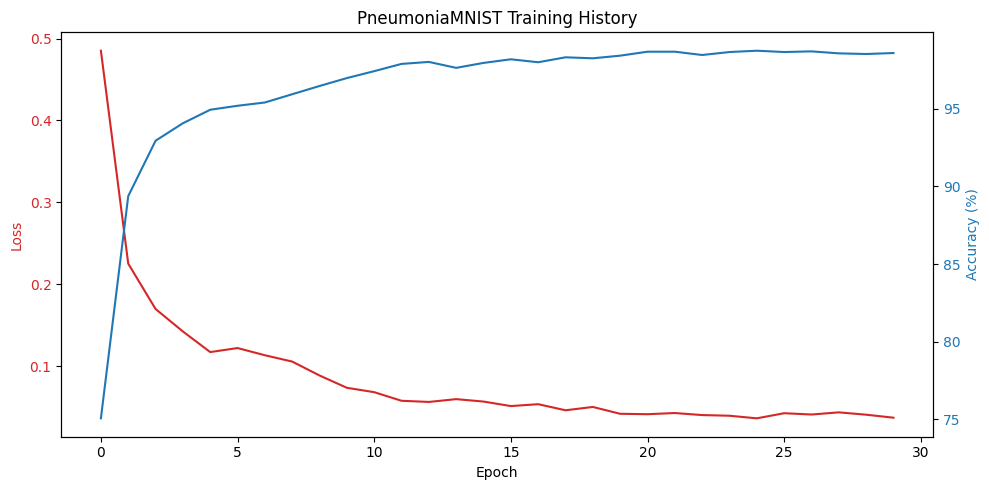

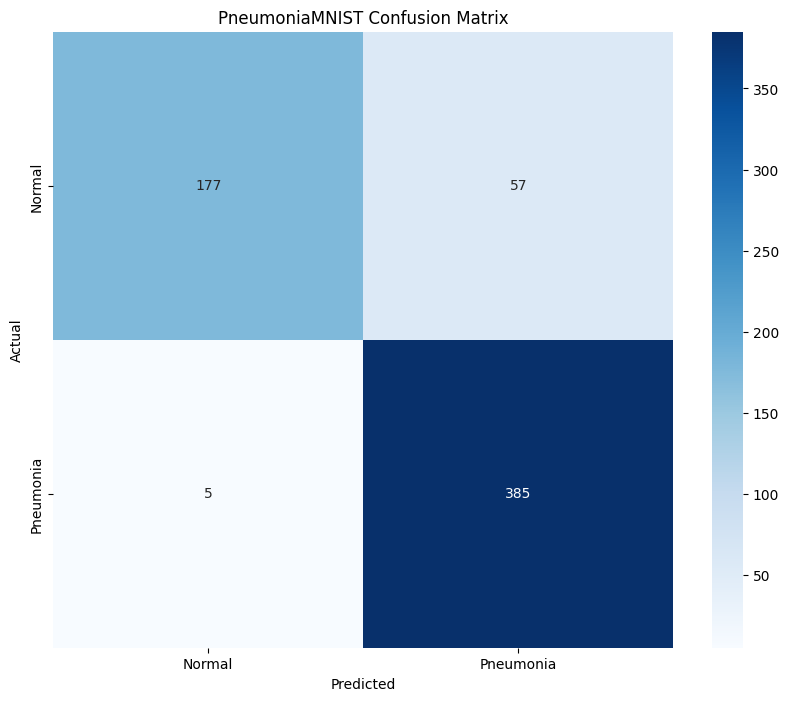

[Evaluating]:   0%|          | 0/2 [00:00<?, ?it/s]

Accuracy on the test set: 90.22%
F1-Score (weighted): 0.90
Recall (weighted): 0.90
Precision (weighted): 0.91


In [32]:
print("\n--- Training LeNet on PneumoniaMNIST ---")
# Calculate class weights for PneumoniaMNIST
class_counts = torch.bincount(torch.tensor(trainset_pneumonia.labels))
total_samples = class_counts.sum().item()
num_classes = len(class_counts)
class_weights = total_samples / (num_classes * class_counts.float())
class_weights = class_weights.to(device)

lenet_pneumonia = LeNetWide(output_size=2)
criterion_pneumonia = nn.CrossEntropyLoss(weight=class_weights) # Apply weighted loss
optimizer_pneumonia = optim.Adam(lenet_pneumonia.parameters(), lr=0.01)
scheduler_pneumonia = optim.lr_scheduler.StepLR(optimizer_pneumonia, step_size=10, gamma=0.1)

history_pneumonia = train_model(lenet_pneumonia, trainloader_pneumonia, criterion_pneumonia, optimizer_pneumonia, num_epochs=30, device=device, scheduler=scheduler_pneumonia)
plot_history(history_pneumonia, title="PneumoniaMNIST Training History")

classes_pneumonia = ['Normal', 'Pneumonia']
plot_confusion_matrix(lenet_pneumonia, testloader_pneumonia, device, classes_pneumonia, title="PneumoniaMNIST Confusion Matrix")
accuracy_pneumonia, f1_pneumonia, recall_pneumonia, precision_pneumonia = evaluate_model(lenet_pneumonia, testloader_pneumonia, device=device)